In [ ]:
import pathlib

In [ ]:
import marimo as mo
import pandas as pd
import requests
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-09-26T19:37:53.125071+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1064-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

pandas  : 2.2.3
seaborn : 0.13.2
teeplot : 1.4.2
requests: 2.34.2
marimo  : 0.23.2

```

## Data

Render a reproduction of Figure 3 from Koopman & Eisenberg,
"An allele-based evolution model of the population spread of
SARS-CoV-2" (medRxiv, <https://doi.org/10.1101/2025.09.15.25335781>).
That figure follows a fully susceptible population through an
initial outbreak of a 2-allele strain, its immune-driven mutational
replacement, and the ensuing damped oscillations in strain
prevalence.
The underlying Madonna ODE-model trajectory is hosted on OSF as
`Fig3.csv` (<https://osf.io/jy59v>) and downloaded below with no
caching-key CLI arguments (this is a visualization notebook).
Columns are keyed `TIME` plus one variable per 2-allele strain
(named by the pair of mutated sites, e.g. `02`, `03`, `12`, `13`):
a `J**` column gives that strain's prevalence, and a `SuscToI**`
column gives the population's fraction still susceptible to
(re)infection by that strain.
In the reference dynamic, strain `02` seeds the initial wave.
Immunity to it wanes unevenly across its two alleles, permitting
mutations to intermediate strains `03` and `12` at vanishingly low
prevalence.
Both intermediates mutate onward to strain `13`, which faces little
standing immunity and comes to dominate later waves.

In [ ]:
def fetch_osf(slug):
    cache_path = pathlib.Path("/tmp") / slug
    url = f"https://osf.io/{slug}/download"
    if not cache_path.exists():
        print(f"downloading {url} -> {cache_path}")
        resp = requests.get(url, allow_redirects=True, timeout=120)
        resp.raise_for_status()
        cache_path.write_bytes(resp.content)
    else:
        print(f"reusing cached {cache_path}")
    print(f"size: {cache_path.stat().st_size} bytes")
    return pd.read_csv(cache_path)

In [ ]:
fig3_df = fetch_osf("jy59v")
fig3_df.columns = [col.replace(":1", "") for col in fig3_df.columns]
print(f"loaded Fig3 dataframe: {fig3_df.shape}")
print(fig3_df.head().to_string(index=False))

downloading https://osf.io/jy59v/download -> /tmp/jy59v
size: 266925 bytes
loaded Fig3 dataframe: (3001, 9)
 TIME  J13      J02  J03  J12  SuscToI02  SuscToI03  SuscToI12  SuscToI13
    0  0.0 0.000010  0.0  0.0   0.999990   0.999990   0.999990   0.999990
    1  0.0 0.000012  0.0  0.0   0.999987   0.999987   0.999987   0.999988
    2  0.0 0.000015  0.0  0.0   0.999983   0.999983   0.999983   0.999985
    3  0.0 0.000018  0.0  0.0   0.999978   0.999979   0.999979   0.999982
    4  0.0 0.000022  0.0  0.0   0.999972   0.999973   0.999973   0.999978


## Strain Dynamics Render

Two panels, sharing a strain color hue but not a y-axis.
Left: per-strain prevalence over time, log-scaled so that the
intermediate strains' vanishingly-low emergence prevalence stays
visible alongside the dominant waves (zero-prevalence stretches,
i.e. before a strain has yet mutated into existence, are left as
gaps).
Right: per-strain fraction of the population susceptible to
reinfection, on a linear scale.

In [ ]:
long_df = fig3_df.melt(
    id_vars="TIME",
    var_name="variable",
    value_name="value",
)
long_df["strain"] = long_df["variable"].str.slice(-2)
is_susceptibility = long_df["variable"].str.startswith("Susc")
long_df["quantity"] = is_susceptibility.map(
    {True: "susceptibility", False: "prevalence"},
)
zeroed_prevalence = (long_df["quantity"] == "prevalence") & (
    long_df["value"] == 0
)
long_df.loc[zeroed_prevalence, "value"] = float("nan")

teeplots/2026-09-26-figrender/a=fig3-strain-dynamics+col=quantity+hue=strain+kind=line+viz=relplot+x=time+y=value+ext=.pdf
teeplots/2026-09-26-figrender/a=fig3-strain-dynamics+col=quantity+hue=strain+kind=line+viz=relplot+x=time+y=value+ext=.png


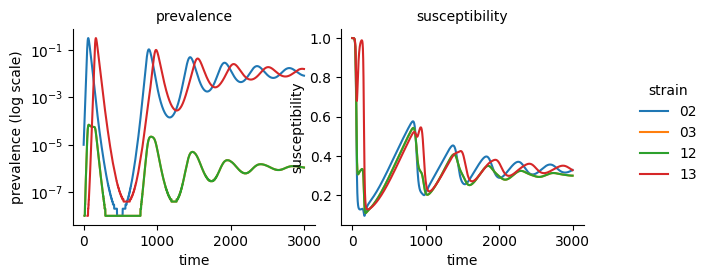

In [ ]:
_strain_order = ["02", "03", "12", "13"]

with tp.teed(
    sns.relplot,
    data=long_df,
    x="TIME",
    y="value",
    hue="strain",
    hue_order=_strain_order,
    col="quantity",
    col_order=["prevalence", "susceptibility"],
    kind="line",
    facet_kws=dict(sharey=False),
    teeplot_outattrs={"a": "fig3-strain-dynamics"},
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as g:
    g.axes_dict["prevalence"].set_yscale("log")
    g.axes_dict["prevalence"].set_ylabel("prevalence (log scale)")
    g.axes_dict["susceptibility"].set_ylabel("susceptibility")
    for _ax in g.axes.flat:
        _ax.set_xlabel("time")
    g.set_titles("{col_name}")
    g.figure.set_size_inches(6, 2.4)
    sns.move_legend(
        g,
        "center left",
        bbox_to_anchor=(1.0, 0.5),
        frameon=False,
        title="strain",
    )